# Sepsis Prediction Example

Sepsis occurs when the immune system responds incorrectly to an infection, typically by overreacting. Without the proper treatment it can lead to death within as little as 12 hours, fortunately modern care facilties can effectively treat sepsis if it is diagnosed in a sufficiently early stage. You can read more about the disease and it's prevalence in [Garvey 2024](https://pmc.ncbi.nlm.nih.gov/articles/PMC11206921/).

Biomedical Informaticians saw this is an opportunity to save lives: if we can predict which patients are high risk for sepsis, then doctors will be able to monitor them more closely and diagnose sepsis earlier.

The Wardi group at UCSD developed a model to detect high risk sepsis patients and alerts physicians if a patient is manifesting early symptoms called [COMPOSER](https://github.com/NematiLab/COMPOSER). They implemented the model in 2 UCSD hospitals and found that all-cause mortality within their observation time decreased by 17% [Boussina 2024](https://www.nature.com/articles/s41746-023-00986-6).

In 2019, the same group (and their collaborators) hosted a hackathon where they curated data for sepsis prediction which will be using today, [link here](https://physionet.org/content/challenge-2019/1.0.0/).

They state the objective as follows:

> The goal of this Challenge is the early detection of sepsis using physiological data. For the purpose of the Challenge, we define sepsis according to the Sepsis-3 guidelines, i.e., a two-point change in the patient's Sequential Organ Failure Assessment (SOFA) score and clinical suspicion of infection (as defined by the ordering of blood cultures or IV antibiotics) (Singer et al., 2016).

> The early prediction of sepsis is potentially life-saving, and we challenge participants to predict sepsis 6 hours before the clinical prediction of sepsis. Conversely, the late prediction of sepsis is potentially life-threatening, and predicting sepsis in non-sepsis patients (or predicting sepsis very early in sepsis patients) consumes limited hospital resources.

Today we're going to build simple models for early diagnosis of sepsis. If this interests you I encourage you to design better models for this hackathon and to reach out to one of the many groups at UCSD working in this growing field.

## Data Exploration

In [52]:
 %%bash
 wget -q https://archive.physionet.org/users/shared/challenge-2019/training_setB.zip
 unzip -q training_setB.zip

One of the biggest challenges in biomedical informatics is that our data is not very clean and not very standardized across different hospital systems and sometimes even between departments in the same hospital.

All of this is made more difficult by the fact that much of Electronic Health Record (EHR) data is Protected Private Information (PPI) so there are additional restrictions on access on data manipulation to ensure patient anonymity and safety.

First let's just do some data exploration using our bash commands. Here's [a refresher](https://github.com/RehanSaeed/Bash-Cheat-Sheet) for those who haven't looked at them often.

You might find the following commands useful:
```
head
less -S
ls
grep
wc -l
cut (has parameters to define seperators and select specific columns in a file)
```

The pipe `|` operator which directs the output of one command to the input of another.

In most bash instances `man [command]` will give you helpful information about a command if you forget though it's not supported in google colab. Instead you can google "man page for [command]" to find the same helpful text.

The [hackathon info page](https://physionet.org/content/challenge-2019/1.0.0/) has information on each column in our dataset.

In [56]:
%%bash
#ls training_setB/ | head
# Your commands here ...
tail training_setB/p100160.psv


48|98|NaN|178|122.5|81|20|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|54|1|0|1|-5.01|3|0
47|98|NaN|146|98|68|20|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|54|1|0|1|-5.01|4|0
47|97|NaN|140|100|76|20|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|54|1|0|1|-5.01|5|0
48|98|36.5|162|110|77|20|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|139|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|54|1|0|1|-5.01|6|0
51|98|NaN|146|97|64|20|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|54|1|0|1|-5.01|7|0
58|96.5|NaN|163.5|108|75|20|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|54|1|0|1|-5.01|8|0
56|99|NaN|136|92|64|20|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|NaN|Na

1. These files are of type ".psv", what do you think psv stands for in this context? (Hint: it's related to csv and tsv files)

2. Each file refers to a specific patient, how could you figure this out if you didn't already know?

3. How old is patient 100160 and do they develop sepsis?


### Data loading

You don't have to understand every line for now but think to yourself why they added specific lines. What error did they see that caused them to load the data in this way because you may see similar errors in the future.

In [57]:
import numpy as np, os, sys

In [59]:
def load_challenge_data(file):
    with open(file, 'r') as f:
        header = f.readline().strip()
        column_names = header.split('|')
        data = np.loadtxt(f, delimiter='|')

    # Ignore SepsisLabel column if present.
    if column_names[-1] == 'SepsisLabel':
        column_names = column_names[:-1]
        labels = data[:, -1]
        data = data[:, :-1]

    return data, labels

In [61]:
# Name of the input directory
input_directory = 'training_setB'

# Find files.
files = []
for f in os.listdir(input_directory):
    if os.path.isfile(os.path.join(input_directory, f)) and not f.lower().startswith('.') and f.lower().endswith('psv'):
        files.append(f)

# Total number of files in the input directory
num_files = len(files)

# SPlit the files into training and testing set
# 80% of data -> Training
# 20% of data -> Testing
shuffled_indices = np.random.permutation(num_files)
train_indices = shuffled_indices[0:int(np.round(0.8*num_files))]
test_indices = shuffled_indices[int(np.round(0.8*num_files)):]

train_files = [] # List of files containing training data
test_files = [] # List of files containing testing data
for i in range(train_indices.shape[0]):
    train_files.append(files[train_indices[i]])

for i in range(test_indices.shape[0]):
    test_files.append(files[test_indices[i]])

train_data = []
train_labels = []
test_data = []
test_labels = []

for i, f in enumerate(train_files):
    # Load data.
    input_file = os.path.join(input_directory, f)
    data_patient, label_patient = load_challenge_data(input_file)
    train_data.append(data_patient)
    train_labels.append(label_patient)

train_data = np.concatenate(train_data)
train_labels = np.concatenate(train_labels)

for i, f in enumerate(test_files):
    # Load data.
    input_file = os.path.join(input_directory, f)
    data_patient, label_patient = load_challenge_data(input_file)
    test_data.append(data_patient)
    test_labels.append(label_patient)

test_data = np.concatenate(test_data)
test_labels = np.concatenate(test_labels)

1. How many sepsis cases and controls do we have in our train and test datasets?

In [71]:
# Your code here:
# ...
sum(test_labels) + sum(train_labels), train_data.shape, test_data.shape

(np.float64(10780.0), (607645, 40), (154350, 40))

## Sepsis Prediction

We will create out prediction models using different kinds of models, such as Logistic Regression model, Random Forest model, os Two layered NN. We can then evaluate their performance after being trained on the same data to see which kind of model is best to use.

The easiet to start with is the Logistic Regression model. This will take the features in the data and fit it to a sigmoid function, which based on a threshold, will classify data as sepsis or not sepsis.

The training data we give to the model can be defined as a matrix X of size n x m, where n is the number of features in the data and m is the number of training samples.

We can then derive an equation:

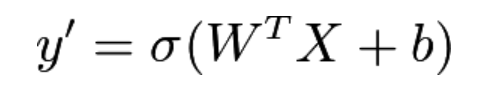

where we multiple the given training data with a weight matrix and add a bias, then send the value through the sigmoid activation function. The sigmoid activation function can be written like this:

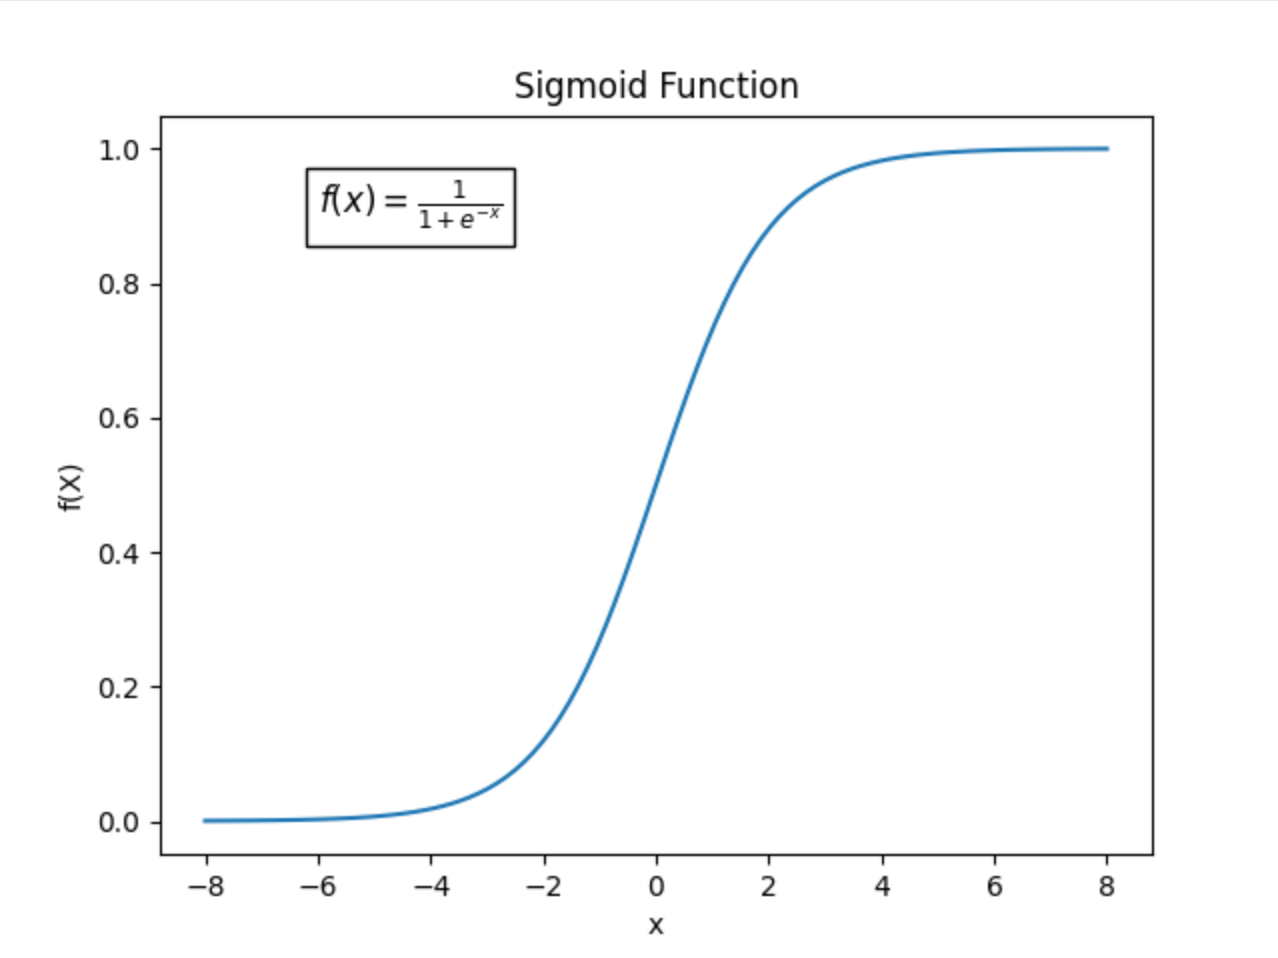

for more info on how the LR model gets trained check out: https://medium.com/analytics-vidhya/logistic-regression-as-a-neural-network-b5d2a1bd696f

We can evaluate our sepsis prediction ML model by using an ROC curve for a logistic regression model.

An ROC curve is a plot that tells how our binary classifier model performs against test data, while comparing the false positive rate and the true positive rate for several tests.

In this example, we wil construct the ROC curves by plotting various true positive rate vs false positive rate data points that will generate a curve, which we can then compare to more advanced models, like a Random Forest Classifier. We can compare the area under the curve for each model to detemine which models has the best performance.


To code this model, we will use the library sklearn and its functions to create the model, train it, and evaluate it (as well as matplot to help plot the ROC curve)

In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import matplotlib.pyplot as plt

Before giving the data for training, we will make all NAN values 0 and standardize the data. This is an important step so that our models does not encounter faulty data, and so that features may be considered equally, no matter what scale they may be on.

In [73]:
x_mean = np.nanmean(train_data, axis = 0)
x_std = np.nanstd(train_data, axis = 0)

# For Nan entries, replace with 0
# For the remaining entries, standardize with mean and std
train_data = np.nan_to_num((train_data - x_mean) / x_std)
test_data = np.nan_to_num((test_data - x_mean) / x_std)

Below, write the code for creating a Logistic Regression model and training it on the training data (create the model then use fit() )

Use this API reference to help:
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

In [74]:
lr_model = LogisticRegression(penalty = 'l2', random_state=0, solver='lbfgs', max_iter = 150, multi_class='multinomial')
lr_model.fit(train_data, train_labels)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=150, multi_class='multinomial', random_state=0)

We can get the output probability scores for the training and testing data

In [76]:
train_pred_score = lr_model.predict_proba(train_data)
test_pred_score = lr_model.predict_proba(test_data)
print("Training prediction score: ", train_pred_score)
print("Testing prediction score: ", test_pred_score)

Training prediction score:  [[0.9923774  0.0076226 ]
 [0.99390593 0.00609407]
 [0.9930159  0.0069841 ]
 ...
 [0.9954987  0.0045013 ]
 [0.99469332 0.00530668]
 [0.99380249 0.00619751]]
Testing prediction score:  [[0.99160725 0.00839275]
 [0.99426471 0.00573529]
 [0.98731413 0.01268587]
 ...
 [0.95910473 0.04089527]
 [0.95060752 0.04939248]
 [0.97067984 0.02932016]]


To get a better understanding of the model's performance, we can use ROC curves and AUC scores.

**What are ROC and AUC scores**

There are many different possible models we could use. To decide which model is best we need an effective way to compare each model.

One way to do so is by comparing their **true positive rates** (TPR), or the percentage of real cases we successfully detected. We want this to be 100%. But a model that always returns "Yes this is Sepsis" will have a 100% TPR, but even patients who are not at risk will be labeled high-risk for sepsis.

So we also must consider the **false positive rate** (FPR) or the percentage of patients with no sepsis that were incorrectly labeled as sepsis by our model.

If we plot the TPR against the FPR of a model we get what's called a receiver operating characteristic or [**ROC curve**](https://en.wikipedia.org/wiki/Receiver_operating_characteristic) (the name is borrowed from electrical engineering).

- **Why is the output of our model a curve instead of a point, shouldn't a single model have a single TPR and FPR?**

Model outputs are typically a real number between 0 and 1. We can arbitrarily choose to set the threshold for a model wherever we want. A threshold sent at 0 will be our first always-sepsis model and a threshold sent at 1 will do the opposite. By changing the threshold from 0 to 1 we can draw the curve seen in ROC plots.

A better model will be up and to the left, a low FPR and a high TPR. We can compare models by calculating the **area unnder the curve** (AUC) for each model we can now compare our models with only a single number.

In this example, we wil construct the ROC curves by varying the threshold value for each model.

For now, we will do this for just the Logistic Regression model

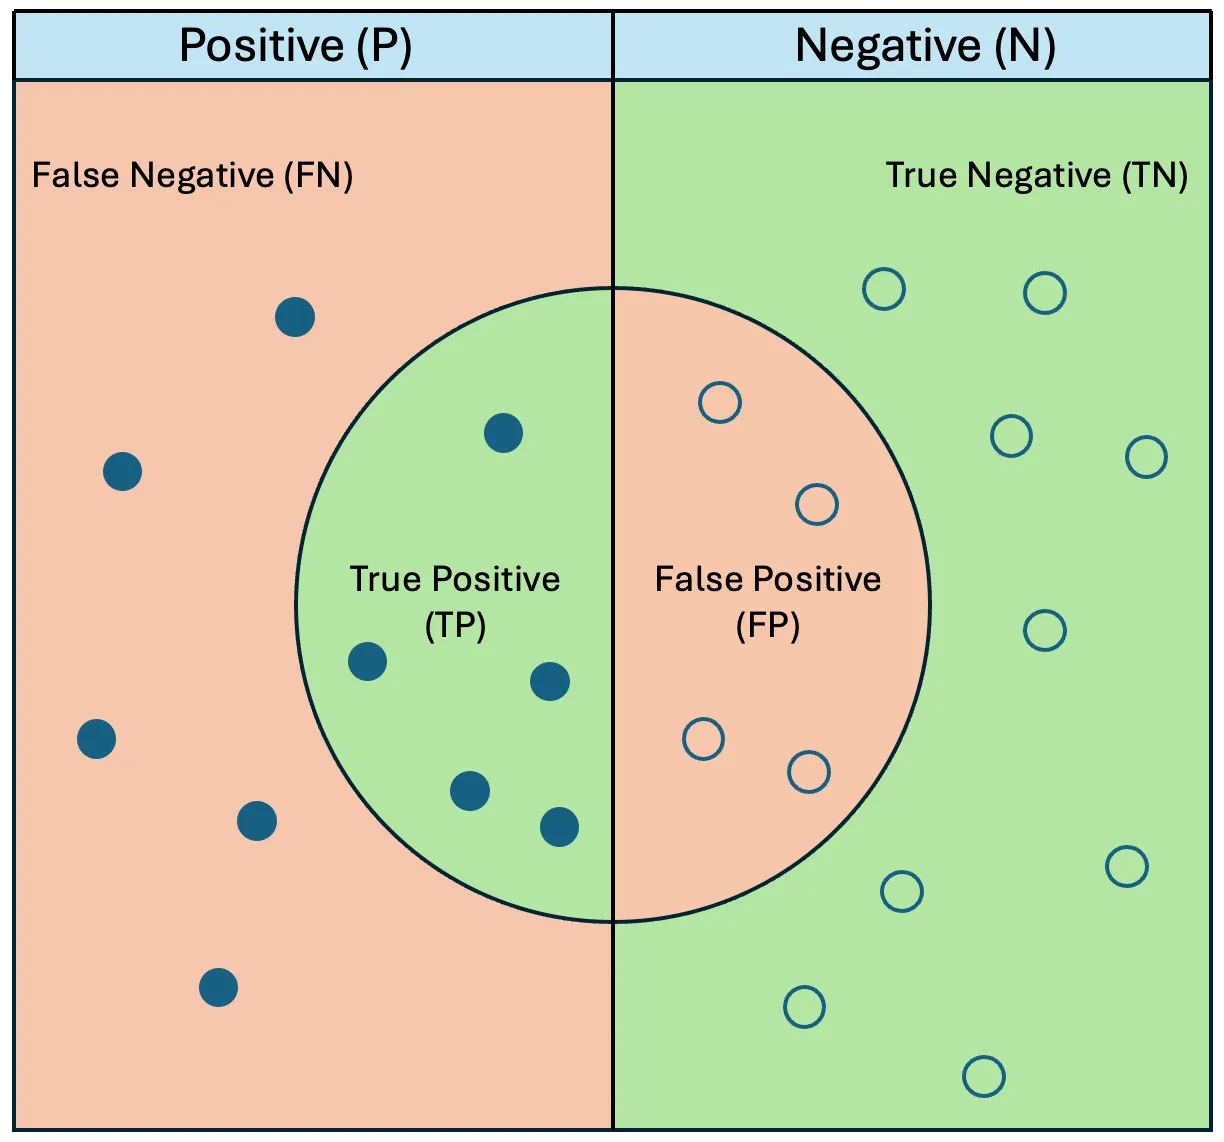

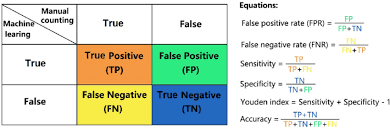

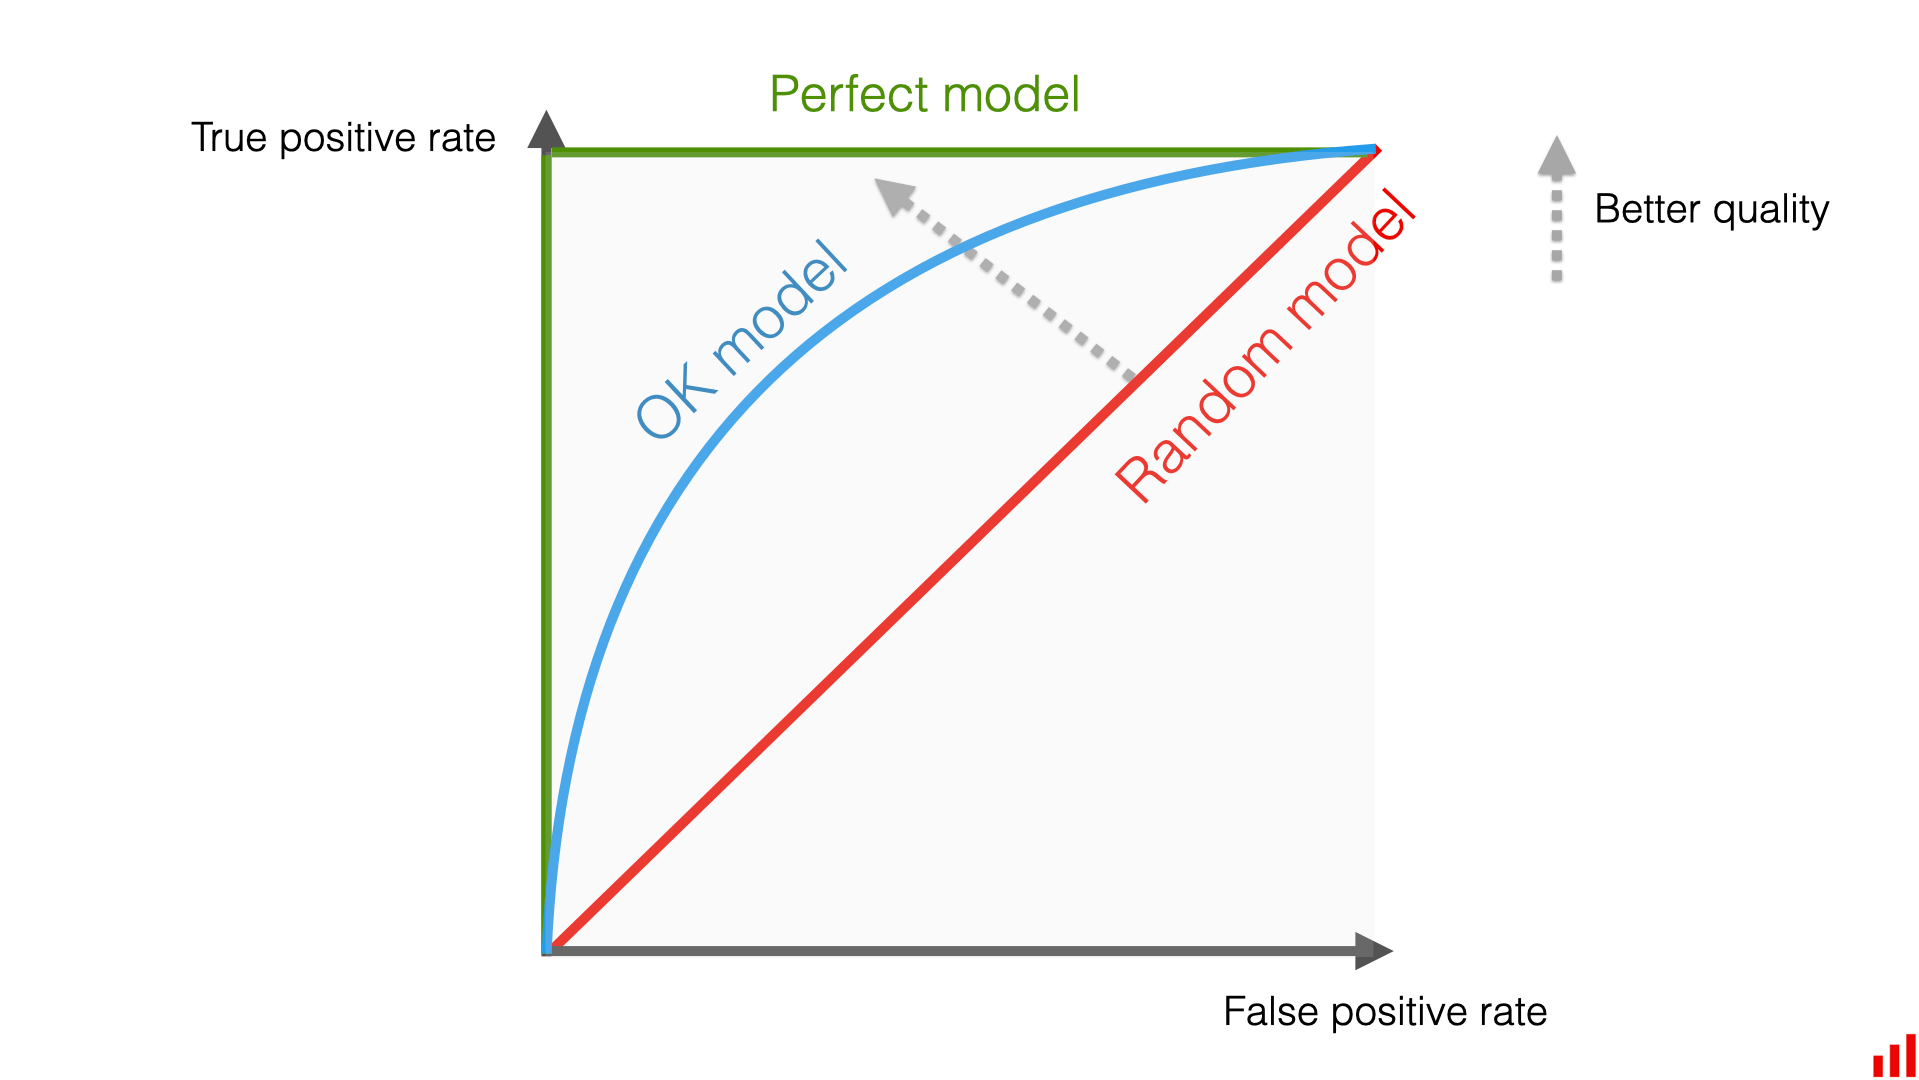

We will use the function in sklearn.metrics, which we already imported before, to help calculate the ROC and AUC

In [77]:
# Compute AUC of training set
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.auc.html
fpr_train, tpr_train, _ = metrics.roc_curve(train_labels, train_pred_score[:,1], pos_label = 1)
train_auc = metrics.auc(fpr_train, tpr_train)

# Compute AUC of testing set
fpr_test, tpr_test, _ = metrics.roc_curve(test_labels, test_pred_score[:,1], pos_label = 1)
test_auc = metrics.auc(fpr_test, tpr_test)

We can then plot the training and testing ROC with matplotlib:

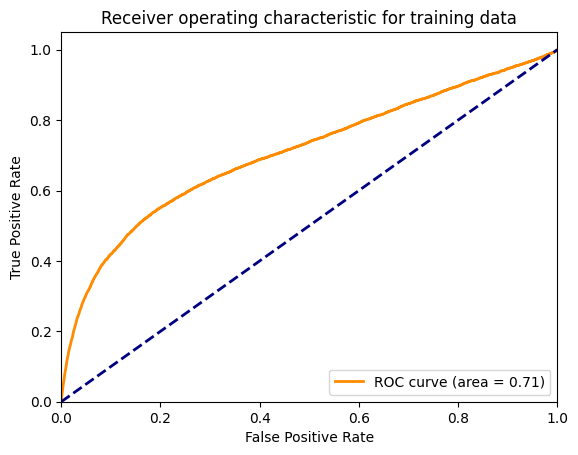

In [79]:
# We will use matplotlib
import matplotlib.pyplot as plt

# Training AUC
plt.figure()
lw = 2
plt.plot(fpr_train, tpr_train, color='darkorange',
         lw=lw, label='ROC curve (area = %0.2f)' % train_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic for training data')
plt.legend(loc="lower right")
plt.show()

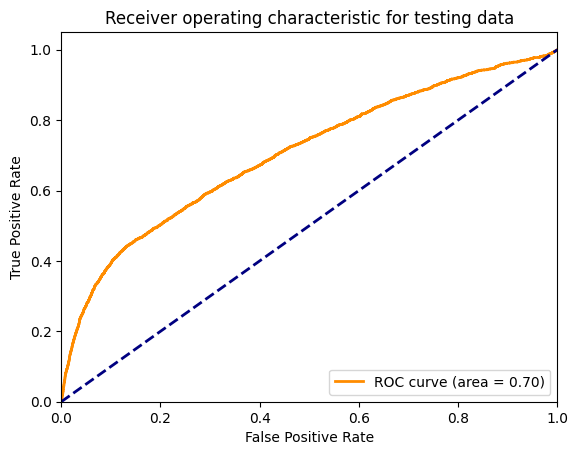

In [80]:
# Testing AUC
plt.figure()
lw = 2
plt.plot(fpr_test, tpr_test, color='darkorange',
         lw=lw, label='ROC curve (area = %0.2f)' % test_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic for testing data')
plt.legend(loc="lower right")
plt.show()

Now lets try this for other models! Add your own to the models_dict and generate the plots with generate_metrics( ... list of names of the models as seen in models_dict ... )

In [81]:
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier

In [82]:
models_dict = {
    "Logistic Regression": LogisticRegression(penalty = 'l2', random_state=0, solver='lbfgs', max_iter = 150, multi_class='multinomial'),
    "Random Forest": RandomForestClassifier(n_estimators=100,
                                            max_depth=10,
                                            min_samples_split=10,
                                            min_samples_leaf=5,
                                            max_features='sqrt',
                                            bootstrap=True,
                                            random_state=0),
    "2 Layer NN": MLPClassifier(hidden_layer_sizes=(10,5),
                                activation='relu',
                                solver='adam',
                                max_iter = 150,
                                alpha=0.0001,
                                learning_rate_init=0.001,
                                batch_size='auto')
}

In [83]:
def generate_metrics(model_names):
  train_metrics_dict = {}
  test_metrics_dict = {}

  for name in model_names:
    print("Running", name, "...")
    model = models_dict[name]
    model.fit(train_data, train_labels)

    train_pred_score = model.predict_proba(train_data)
    test_pred_score = model.predict_proba(test_data)

    fpr_train, tpr_train, _ = metrics.roc_curve(train_labels, train_pred_score[:,1], pos_label = 1)
    train_auc = metrics.auc(fpr_train, tpr_train)

    fpr_test, tpr_test, _ = metrics.roc_curve(test_labels, test_pred_score[:,1], pos_label = 1)
    test_auc = metrics.auc(fpr_test, tpr_test)

    train_metrics_dict[name] = [fpr_train, tpr_train, train_auc]
    test_metrics_dict[name] = [fpr_test, tpr_test, test_auc]

  plt.figure()
  lw = 2
  plt.plot([0, 1], [0, 1], color='black', lw=lw, linestyle='--', label="Random Guess")
  for name in model_names:
    train_metrics = train_metrics_dict[name]
    plt.plot(train_metrics[0], train_metrics[1],
              lw=lw, label= name+' ROC curve (area = %0.2f)' % train_metrics[2])

  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('Receiver operating characteristic for training data')
  plt.legend(loc="lower right")
  plt.grid()
  plt.show()


  plt.figure()
  lw = 2
  plt.plot([0, 1], [0, 1], color='black', lw=lw, linestyle='--', label="Random Guess")

  for name in model_names:
    test_metrics = test_metrics_dict[name]
    plt.plot(test_metrics[0], test_metrics[1],
              lw=lw, label= name+' ROC curve (area = %0.2f)' % test_metrics[2])

  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('Receiver operating characteristic for testing data')
  plt.legend(loc="lower right")
  plt.grid()
  plt.show()

Running Logistic Regression ...


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


Running 2 Layer NN ...
Running Random Forest ...


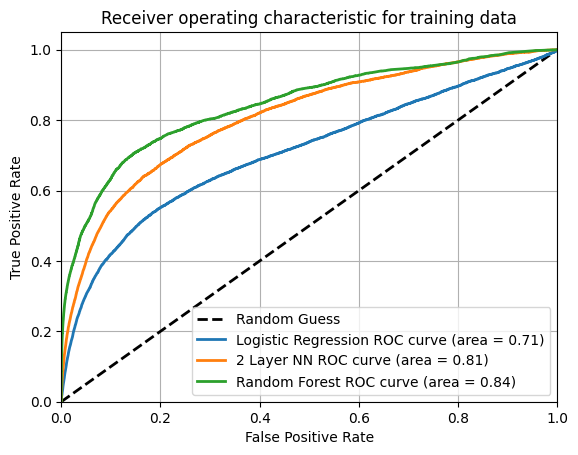

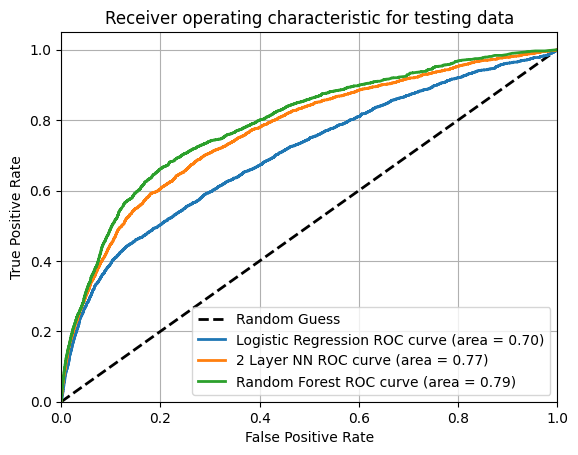

In [85]:
generate_metrics(["Logistic Regression","2 Layer NN", "Random Forest"])